In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
file_path = '/content/MyDrive/loan_prediction.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: Could not find {file_path}. Please check the file name and path.")

# Display basic information
display(df.head())
print(df.info())

Error: Could not find /content/MyDrive/loan_prediction.csv. Please check the file name and path.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 62.4+ KB
None


In [18]:
# DATA PREPROCESSING
# A. Drop Irrelevant Columns
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])
    print("Dropped 'Loan_ID' column.")

# B. Handle Missing Values
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# Numerical columns: fill with median
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

print("Missing values handled (Categorical: Mode, Numerical: Median).")
print(df.isnull().sum())

Missing values handled (Categorical: Mode, Numerical: Median).
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [19]:
# EXPLORATORY DATA ANALYSIS
# Plot 1: Distribution of Loan Status
fig_status = px.histogram(df, x='Loan_Status', color='Loan_Status', title='Distribution of Loan Status')
fig_status.show()

# Plot 2: Loan Approval by Credit History
fig_credit = px.histogram(df, x='Credit_History', color='Loan_Status', barmode='group',
                          title='Loan Approval vs. Credit History')
fig_credit.show()

# Plot 3: Applicant Income Distribution by Gender
fig_income = px.box(df, x='Gender', y='ApplicantIncome', color='Loan_Status',
                    title='Applicant Income vs Loan Status by Gender')
fig_income.show()

In [20]:
# FEATURE ENGINEERING
# Separate target variable (y) from features (X)
y = df['Loan_Status'].map({'Y': 1, 'N': 0})
X = df.drop(columns=['Loan_Status'])

# Convert categorical variables into numerical using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Shape of features after One-Hot Encoding: {X_encoded.shape}")

Shape of features after One-Hot Encoding: (614, 14)


In [21]:
# DATA SPLITTING AND SCALING
#Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Scale the features (Crucial for algorithms like SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


In [22]:
# MODEL TRAINING AND EVALUAITON
# A. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

print("\n=== Random Forest Classifier ===")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.2f}")
print("Classification Report:")
print(classification_report(y_test, rf_predictions))

# B. Support Vector Classifier (SVC)
svc_model = SVC(random_state=42, kernel='rbf', class_weight='balanced')
svc_model.fit(X_train_scaled, y_train)
svc_predictions = svc_model.predict(X_test_scaled)

print("\n=== Support Vector Classifier (SVC) ===")
print(f"Accuracy: {accuracy_score(y_test, svc_predictions):.2f}")
print("Classification Report:")
print(classification_report(y_test, svc_predictions))


=== Random Forest Classifier ===
Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123


=== Support Vector Classifier (SVC) ===
Accuracy: 0.76
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



In [23]:
from sklearn.model_selection import GridSearchCV

print("\n--- Fine-Tuning Random Forest ---")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
rf_pred_tuned = best_rf.predict(X_test_scaled)

print(f"Tuned Random Forest Accuracy: {accuracy_score(y_test, rf_pred_tuned):.2f}")
print(classification_report(y_test, rf_pred_tuned))


--- Fine-Tuning Random Forest ---
Tuned Random Forest Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



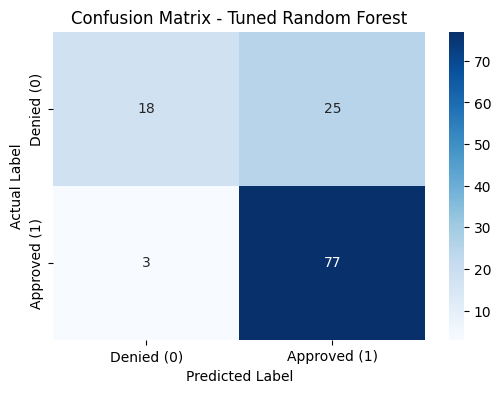

In [15]:
# confusion matrix
cm = confusion_matrix(y_test, rf_pred_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Denied (0)', 'Approved (1)'],
            yticklabels=['Denied (0)', 'Approved (1)'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()